In [1]:
from datasets import load_dataset

# Load subjqa by pointing to its Parquet files on the Hub
# Each domain has its own files under refs/convert/parquet
subjqa = load_dataset("parquet", data_files={
    "train": "hf://datasets/megagonlabs/subjqa@refs/convert/parquet/electronics/train/0000.parquet",
    "test": "hf://datasets/megagonlabs/subjqa@refs/convert/parquet/electronics/test/0000.parquet",
    "validation": "hf://datasets/megagonlabs/subjqa@refs/convert/parquet/electronics/validation/0000.parquet",
})

print(subjqa)

c:\Users\omm47\PythonEnvs\ai_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['domain', 'nn_mod', 'nn_asp', 'query_mod', 'query_asp', 'q_reviews_id', 'question_subj_level', 'ques_subj_score', 'is_ques_subjective', 'review_id', 'id', 'title', 'context', 'question', 'answers'],
        num_rows: 1295
    })
    test: Dataset({
        features: ['domain', 'nn_mod', 'nn_asp', 'query_mod', 'query_asp', 'q_reviews_id', 'question_subj_level', 'ques_subj_score', 'is_ques_subjective', 'review_id', 'id', 'title', 'context', 'question', 'answers'],
        num_rows: 358
    })
    validation: Dataset({
        features: ['domain', 'nn_mod', 'nn_asp', 'query_mod', 'query_asp', 'q_reviews_id', 'question_subj_level', 'ques_subj_score', 'is_ques_subjective', 'review_id', 'id', 'title', 'context', 'question', 'answers'],
        num_rows: 255
    })
})


In [2]:
subjqa["train"][1]

{'domain': 'electronics',
 'nn_mod': 'harsh',
 'nn_asp': 'high',
 'query_mod': 'not strong',
 'query_asp': 'bass',
 'q_reviews_id': '7c46670208f7bf5497480fbdbb44561a',
 'question_subj_level': 1,
 'ques_subj_score': 0.5,
 'is_ques_subjective': False,
 'review_id': 'ce76793f036494eabe07b33a9a67288a',
 'id': 'd476830bf9282e2b9033e2bb44bbb995',
 'title': 'B00001P4ZH',
 'context': 'To anyone who hasn\'t tried all the various types of headphones, it is important to remember exactly what these are: cheap portable on-ear headphones. They give a totally different sound then in-ears or closed design phones, but for what they are I would say they\'re good. I currently own six pairs of phones, from stock apple earbuds to Sennheiser HD 518s. Gave my Portapros a run on both my computer\'s sound card and mp3 player, using 256 kbps mp3s or better. The clarity is good and they\'re very lightweight. The folding design is simple but effective. The look is certainly retro and unique, although I didn\'t fi

In [3]:
subjqa["train"]["answers"][1]

{'text': ['Bass is weak as expected',
  'Bass is weak as expected, even with EQ adjusted up'],
 'answer_start': [1302, 1302],
 'answer_subj_level': [1, 1],
 'ans_subj_score': [0.5083333253860474, 0.5083333253860474],
 'is_ans_subjective': [True, True]}

In [4]:
import pandas as pd

dfs = {split: dset.to_pandas() for split, dset in subjqa.flatten().items()}

for split, df in dfs.items():
  print(f"Number of questions in {split}: {df['id'].nunique()}")

Number of questions in train: 1295
Number of questions in test: 358
Number of questions in validation: 255


In [5]:
dfs["train"].head()

,domain,nn_mod,nn_asp,query_mod,query_asp,q_reviews_id,question_subj_level,ques_subj_score,is_ques_subjective,review_id,id,title,context,question,answers.text,answers.answer_start,answers.answer_subj_level,answers.ans_subj_score,answers.is_ans_subjective
0,electronics,great,bass response,excellent,bass,0514ee34b672623dff659334a25b599b,5,0.50,False,882b1e2745a4779c8f17b3d4406b91c7,2543d296da9766d8d17d040ecc781699,B00001P4ZH,"I have had Koss headphones in the past, Pro 4A...",How is the bass?,[],[],[],[],[]
1,electronics,harsh,high,not strong,bass,7c46670208f7bf5497480fbdbb44561a,1,0.50,False,ce76793f036494eabe07b33a9a67288a,d476830bf9282e2b9033e2bb44bbb995,B00001P4ZH,To anyone who hasn't tried all the various typ...,Is this music song have a goo bass?,"[Bass is weak as expected, Bass is weak as exp...","[1302, 1302]","[1, 1]","[0.5083333, 0.5083333]","[True, True]"
2,electronics,neutral,sound,present,bass,8fbf26792c438aa83178c2d507af5d77,1,0.50,False,d040f2713caa2aff0ce95affb40e12c2,455575557886d6dfeea5aa19577e5de4,B00001P4ZH,I have had many sub-$100 headphones from $5 Pa...,How is the bass?,[The only fault in the sound is the bass],[650],[2],[0.6333333],[True]
3,electronics,muddy,bass,awesome,bass,9876fd06ed8f075fcad70d1e30e7e8be,1,0.50,False,043e7162df91f6ea916c790c8a6f6b22,6895a59b470d8feee0f39da6c53a92e5,B00001WRSJ,My sister's Bose headphones finally died and s...,How is the audio bass?,[the best of all of them],[1609],[1],[0.3],[False]
4,electronics,perfect,bass,incredible,sound,16506b53e2d4c2b6a65881d9462256c2,1,0.65,True,29ccd7e690050e2951be49289e915382,7a2173c502da97c5bd5950eae7cd7430,B00001WRSJ,Wow. Just wow. I'm a 22 yr old with a crazy ob...,Why do I have an incredible sound?,"[The sound is so crisp, crazy obsession with s...","[141, 38]","[1, 1]","[0.40833333, 0.40833333]","[False, False]"


In [6]:
qa_cols = ["title","question", "answers.text", "answers.answer_start", "context"]

sample_df = dfs["train"][qa_cols].sample(2, random_state = 7)
sample_df

,title,question,answers.text,answers.answer_start,context
791,B005DKZTMG,Does the keyboard lightweight?,[this keyboard is compact],[215],I really like this keyboard. I give it 4 star...
1159,B00AAIPT76,How is the battery?,[],[],I bought this after the first spare gopro batt...


In [7]:
start_idx = sample_df["answers.answer_start"].iloc[0][0]
end_idx = start_idx + len(sample_df["answers.text"].iloc[0][0])
sample_df["context"].iloc[0][start_idx:end_idx]

'this keyboard is compact'

In [8]:
import matplotlib.pyplot as plt

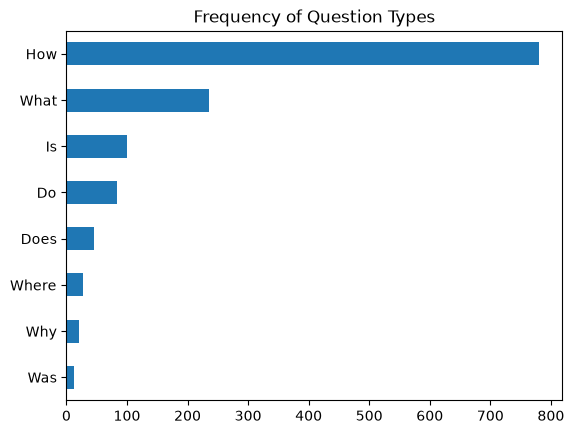

In [9]:
counts = {}
question_types = ["What", "How", "Is", "Does", "Do", "Was", "Where", "Why"]
for q in question_types:
 counts[q] = dfs["train"]["question"].str.startswith(q).value_counts()[True]
pd.Series(counts).sort_values().plot.barh()
plt.title("Frequency of Question Types")
plt.show()


In [10]:
for question_type in ["How", "What", "Is"]:
  for question in (
    dfs["train"][dfs["train"].question.str.startswith(question_type)].sample(n = 3, random_state = 42)["question"]):
    print(question)

How is the camera?
How do you like the control?
How fast is the charger?
What is direction?
What is the quality of the construction of the bag?
What is your impression of the product?
Is this how zoom works?
Is sound clear?
Is it a wireless keyboard?


## Tokenizing text for OA

In [11]:
from transformers import AutoTokenizer

model_ckpt = "deepset/minilm-uncased-squad2"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

c:\Users\omm47\PythonEnvs\ai_env\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\omm47\.cache\huggingface\hub\models--deepset--minilm-uncased-squad2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [12]:
question = "How much music can this hold?"
context = """An MP3 is about 1 MB/minute, so about 6000 hours depending on \ file size."""

inputs = tokenizer(question, context, return_tensors = "pt")

<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:2: SyntaxWarning: invalid escape sequence '\ '
C:\Users\omm47\AppData\Local\Temp\ipykernel_10812\1896767096.py:2: SyntaxWarning: invalid escape sequence '\ '
  context = """An MP3 is about 1 MB/minute, so about 6000 hours depending on \ file size."""


In [13]:
print(tokenizer.decode(inputs["input_ids"][0]))

[CLS] how much music can this hold? [SEP] an mp3 is about 1 mb / minute, so about 6000 hours depending on \ file size. [SEP]


In [ ]:
import torch
from transformers import AutoModelForQuestionAnswering

model = AutoModelForQuestionAnswering.from_pretrained(model_ckpt)

In [ ]:
with torch.no_grad():
  outputs = model(**inputs)

print(outputs)

QuestionAnsweringModelOutput(loss=None, start_logits=tensor([[-0.7600, -4.7565, -5.4027, -5.2368, -5.2771, -5.4985, -4.9769, -6.1621,
         -0.7600,  0.6526,  0.0474, -1.4596,  4.0708,  5.2617, -0.7022, -3.8406,
         -1.4190, -4.6270, -1.4310,  3.7721,  4.5929, -0.3631, -3.3237, -5.1965,
         -3.1124, -3.4640, -4.2704, -4.4887, -0.7600]]), end_logits=tensor([[-0.7715, -5.4826, -5.0251, -5.1502, -5.4228, -5.5347, -5.1739, -4.6997,
         -0.7715, -3.6354, -0.5732, -3.6876, -2.8507, -0.8947,  0.6140, -2.4160,
          5.4288,  0.2895, -3.0944, -3.3933,  0.7722,  5.4368, -0.8595, -5.0447,
         -4.4632, -4.1436, -1.1829, -0.3302, -0.7715]]), hidden_states=None, attentions=None)


In [ ]:
start_logits = outputs.start_logits
end_logits = outputs.end_logits

In [ ]:
print(f"Input IDs shape: {inputs.input_ids.size()}")
print(f"Start logits shape: {start_logits.size()}")
print(f"End logits shape: {end_logits.size()}")

Input IDs shape: torch.Size([1, 29])
Start logits shape: torch.Size([1, 29])
End logits shape: torch.Size([1, 29])


In [ ]:
start_idx = torch.argmax(start_logits)
end_idx = torch.argmax(end_logits) + 1

In [ ]:
answer_span = inputs["input_ids"][0][start_idx : end_idx]
answer = tokenizer.decode(answer_span)

print(answer)

1 mb / minute, so about 6000 hours


## Full Pipeline

In [ ]:
from transformers import pipeline

pipe = pipeline("question-answering", model = model, tokenizer = tokenizer)

Device set to use cpu


In [ ]:
pipe(question=question, context=context, topk=3)

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/question_answering.py:339: UserWarning: topk parameter is deprecated, use top_k instead
  warnings.warn("topk parameter is deprecated, use top_k instead", UserWarning)


[{'score': 0.23801982402801514,
  'start': 16,
  'end': 48,
  'answer': '1 MB/minute, so about 6000 hours'},
 {'score': 0.23613353073596954,
  'start': 16,
  'end': 27,
  'answer': '1 MB/minute'},
 {'score': 0.12194949388504028,
  'start': 38,
  'end': 48,
  'answer': '6000 hours'}]

In [ ]:
pipe(question="Why is there no data?", context=context, handle_impossible_answer=True)

{'score': 0.9193894863128662, 'start': 0, 'end': 0, 'answer': ''}

## Handling long passages

1. The Problem: Why Truncation Fails for QA
The Concept:
Every Transformer model has a maximum sequence length (e.g., 512 tokens for MiniLM). If your input is longer than this, you must cut it somehow.

- Example: If a 1,000-token review says the battery life is great in the first sentence, but mentions "waterproof at 30m" at token 800, truncating to 512 tokens removes the waterproof information entirely.

2. The Solution: Sliding Window
The Concept:
Instead of looking at the whole document once, you slide a "window" across it. You break the long context into overlapping chunks, each small enough to fit inside the model's limit.


In [ ]:
example = dfs["train"].iloc[0][["question", "context"]]
example["context"]

'I have had Koss headphones in the past, Pro 4AA and QZ-99.  The Koss Portapro is portable AND has great bass response.  The work great with my Android phone and can be "rolled up" to be carried in my motorcycle jacket or computer bag without getting crunched.  They are very light and do not feel heavy or bear down on your ears even after listening to music with them on all day.  The sound is night and day better than any ear-bud could be and are almost as good as the Pro 4AA.  They are "open air" headphones so you cannot match the bass to the sealed types, but it comes close. For $32, you cannot go wrong.'

3. The Code

In [ ]:
tokenized_example = tokenizer(
    example["question"],
    example["context"],
    return_overflowing_tokens = True,
    max_length = 100,
    stride = 25,
    truncation = True
)

In [ ]:
for idx, window in enumerate(tokenized_example["input_ids"]):
    print(f"Window #{idx} has {len(window)} tokens")

Window #0 has 100 tokens
Window #1 has 88 tokens


What this tells us:
- The original (question, context) pair was too long to fit in 100 tokens.
- The tokenizer created 2 windows.
- Window 0 is exactly 100 tokens (it hit the limit).
- Window 1 is only 88 tokens because it contains the remaining tail end of the context.

In [ ]:
for window in tokenized_example["input_ids"]:
    print(f"{tokenizer.decode(window)} \n")

[CLS] how is the bass? [SEP] i have had koss headphones in the past, pro 4aa and qz - 99. the koss portapro is portable and has great bass response. the work great with my android phone and can be " rolled up " to be carried in my motorcycle jacket or computer bag without getting crunched. they are very light and do not feel heavy or bear down on your ears even after listening to music with them on all day. the sound is [SEP] 

[CLS] how is the bass? [SEP] and do not feel heavy or bear down on your ears even after listening to music with them on all day. the sound is night and day better than any ear - bud could be and are almost as good as the pro 4aa. they are " open air " headphones so you cannot match the bass to the sealed types, but it comes close. for $ 32, you cannot go wrong. [SEP] 



4. What Happens Next in a Real Pipeline?
- When you use sliding windows during training or inference, you need to handle a few extra things:
- **1.Multiple predictions:** The model will output a start/end span for each window. You must collect all predictions and pick the one with the highest confidence score.
- **2.Mapping back to the original context:** The predicted token indices are relative to the window, not the original document. You need to map them back to the original character positions.
- **3.Handling impossible answers:** If a window doesn't contain the answer, the model should ideally predict the `[CLS]` token (indicating no answer in this chunk).
- **4.In the `datasets` library:** When you process a whole dataset, you typically use `map()` with a function that applies this tokenization strategy to every example, exploding one long-context example into multiple `(question, window)` training examples.

## **Haystack QA Pipeline**

The Concept:
You need a place to store all your reviews. Haystack supports several backends (In-memory, Elasticsearch, FAISS, Milvus).

Setting up Elasticsearch

In [ ]:
url = """https://artifacts.elastic.co/downloads/elasticsearch/\
elasticsearch-7.9.2-linux-x86_64.tar.gz"""
!wget -nc -q {url}
!tar -xzf elasticsearch-7.9.2-linux-x86_64.tar.gz

In [ ]:
import os
from subprocess import Popen, PIPE, STDOUT

!chown -R daemon:daemon elasticsearch-7.9.2
es_server = Popen(
    args=['elasticsearch-7.9.2/bin/elasticsearch'],
    stdout=PIPE,
    stderr=STDOUT,
    preexec_fn=lambda: os.setuid(1)
)
!sleep 30

In [ ]:
!curl -X GET "localhost:9200/?pretty"

curl: (7) Failed to connect to localhost port 9200 after 0 ms: Connection refused


In [ ]:
from haystack.document_stores import ElasticsearchDocumentStore

document_store = ElasticsearchDocumentStore(
    return_embedding=True
)

In [ ]:
for split, df in dfs.items():
    docs = [
        {
            "content": row["context"],
            "meta": {
                "item_id": row["title"],
                "question_id": row["id"],
                "split": split
            }
        }
        for _, row in df.drop_duplicates(subset="context").iterrows()
    ]
    document_store.write_documents(docs, index="document")

In [ ]:
print(f"Loaded {document_store.get_document_count()} documents")
# Loaded 1615 documents

Loaded 1615 documents


**Retriever: Finding Relevant Reviews Fast**<br>
The Concept:
A retriever is a fast, lightweight search system. It doesn't understand deep meaning — it just finds documents that look relevant to the query.

In [ ]:
query = "What is the capital of France?"

results = document_store.query(
    query=query,
    top_k=5
)

for doc in results:
    print(doc.content)

I thought I would be thrilled with this, however do your research as to what it actually can do, and what it can not do.I am disappointed. Even though the price is relatively low, I would rather pay more to get more. Sony, WD, Roku, all have similar devices , but not exactly. Please, before buying , do check out what this unit is capable of and specifically what it is not intended to do.
You have read about what the router can do. I am not going to regurgitate it all back to you again, instead I will go over what stood out and what I had problems with when using this router in my network.As far as what good things stood out the router has 3 external antennas that are detachable allowing you to upgrade the antennas if you want. I like having antenna options. There are dedicated wireless and power on / off switches on the rear of router allowing easy rebooting and absolute control over the wireless signal. I was able to achieve my rated download and upload speeds from my ISP. I did not h